# Housing Market Metrics Around Extreme Climate Events

**Purpose.** Show only the project housing-market metrics around the configured
event windows, first across all affected county-events and then grouped by FEMA
National Risk Index rating.

This notebook queries persisted `analysis.*` marts. Production database code owns
event selection, deduplication, window alignment, completeness, and aggregation.

## Setup and canonical event-window definition

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "quoll.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
con = duckdb.connect(str(ROOT / "data" / "quoll.duckdb"), read_only=True)

config = con.execute("SELECT * FROM analysis.event_window_config ORDER BY parameter").df()
display(config)

,parameter,value
0,cohort_rule,Eligibility is evaluated separately for each h...
1,comparison_method,Descriptive median across affected county-even...
2,completeness_rule,A county-event-metric must contain every requi...
3,county_event_deduplication,Exact event_key: source + source event id + co...
4,event_end_definition,Calendar month containing incident/event end t...
5,event_start_definition,Calendar month containing incident/event begin...
6,excluded_fema_incident_types,"Biological, Dam/Levee Break, Chemical, Terrori..."
7,included_event_sources,FEMA declarations and NOAA Storm Events
8,multiple_events_per_county,Retained as distinct county-event lines
9,noaa_damage_threshold_usd,1000000000


### Interpretation of the configuration

- **Extreme events:** qualifying FEMA declarations plus NOAA Storm Events with at
  least the configured total-damage threshold.
- **FEMA inclusion:** county records with valid incident starts, excluding the listed
  non-climate or out-of-scope incident types.
- **NOAA inclusion:** county-resolved events with valid starts and damage at or above
  the threshold.
- **County-event deduplication:** exact production `event_key`; distinct events in the
  same county remain distinct.
- **Start/end:** non-positive months align to event start; positive months align to
  event end. Missing ends use the start.
- **Completeness:** a county-event-metric must contain every required month for the
  selected horizon.
- **Overlap and repeated counties:** retained. One housing observation may contribute
  to multiple distinct event windows.
- **Comparison:** descriptive medians of affected county-events. No external control
  baseline is used in this notebook.

## Event scope and cohort

In [2]:
event_scope = con.execute(
    '''
    SELECT
        event_source,
        count(*) AS county_events,
        count(DISTINCT fips) AS counties,
        count(DISTINCT source_event_id) AS source_events,
        min(event_start_month) AS first_event_month,
        max(event_start_month) AS last_event_month
    FROM analysis.extreme_events_county
    GROUP BY event_source
    ORDER BY event_source
    '''
).df()
display(event_scope)

overlap = con.execute(
    '''
    WITH ranges AS (
        SELECT DISTINCT event_key, fips, event_start_month, event_end_month
        FROM analysis.extreme_events_county
    )
    SELECT
        count(*) AS overlapping_event_pairs,
        count(DISTINCT a.fips) AS counties_with_overlap
    FROM ranges a
    JOIN ranges b
      ON a.fips = b.fips
     AND a.event_key < b.event_key
     AND a.event_start_month <= b.event_end_month
     AND b.event_start_month <= a.event_end_month
    '''
).df()
display(overlap)

,event_source,county_events,counties,source_events,first_event_month,last_event_month
0,fema,14990,2768,1247,2013-01-01,2024-12-01
1,noaa,37,33,36,2016-04-01,2024-09-01


,overlapping_event_pairs,counties_with_overlap
0,3713,1329


## Sample sizes at every horizon

In [3]:
sample_sizes = con.execute(
    '''
    SELECT
        aggregation_level,
        risk_rating,
        horizon_months,
        metric_name,
        max(county_event_count) AS complete_county_events,
        max(county_count) AS counties
    FROM analysis.housing_event_window_summary
    GROUP BY aggregation_level, risk_rating, horizon_months, metric_name
    ORDER BY aggregation_level, risk_rating, horizon_months, metric_name
    '''
).df()
display(sample_sizes)

,aggregation_level,risk_rating,horizon_months,metric_name,complete_county_events,counties
0,all_counties,None,12,avg_sale_to_list_yoy,9706,1906
1,all_counties,None,12,homes_sold_yoy,10436,2077
2,all_counties,None,12,housing_market_index,10439,2079
3,all_counties,None,12,inventory_yoy,10202,2054
4,all_counties,None,12,median_dom_yoy,10315,2060
...,...,...,...,...,...,...
235,nri_risk_rating,Very Low,60,inventory_yoy,1049,436
236,nri_risk_rating,Very Low,60,median_dom_yoy,1068,435
237,nri_risk_rating,Very Low,60,median_ppsf_yoy,1057,432
238,nri_risk_rating,Very Low,60,new_listings_yoy,984,408


## Aggregate results across all counties

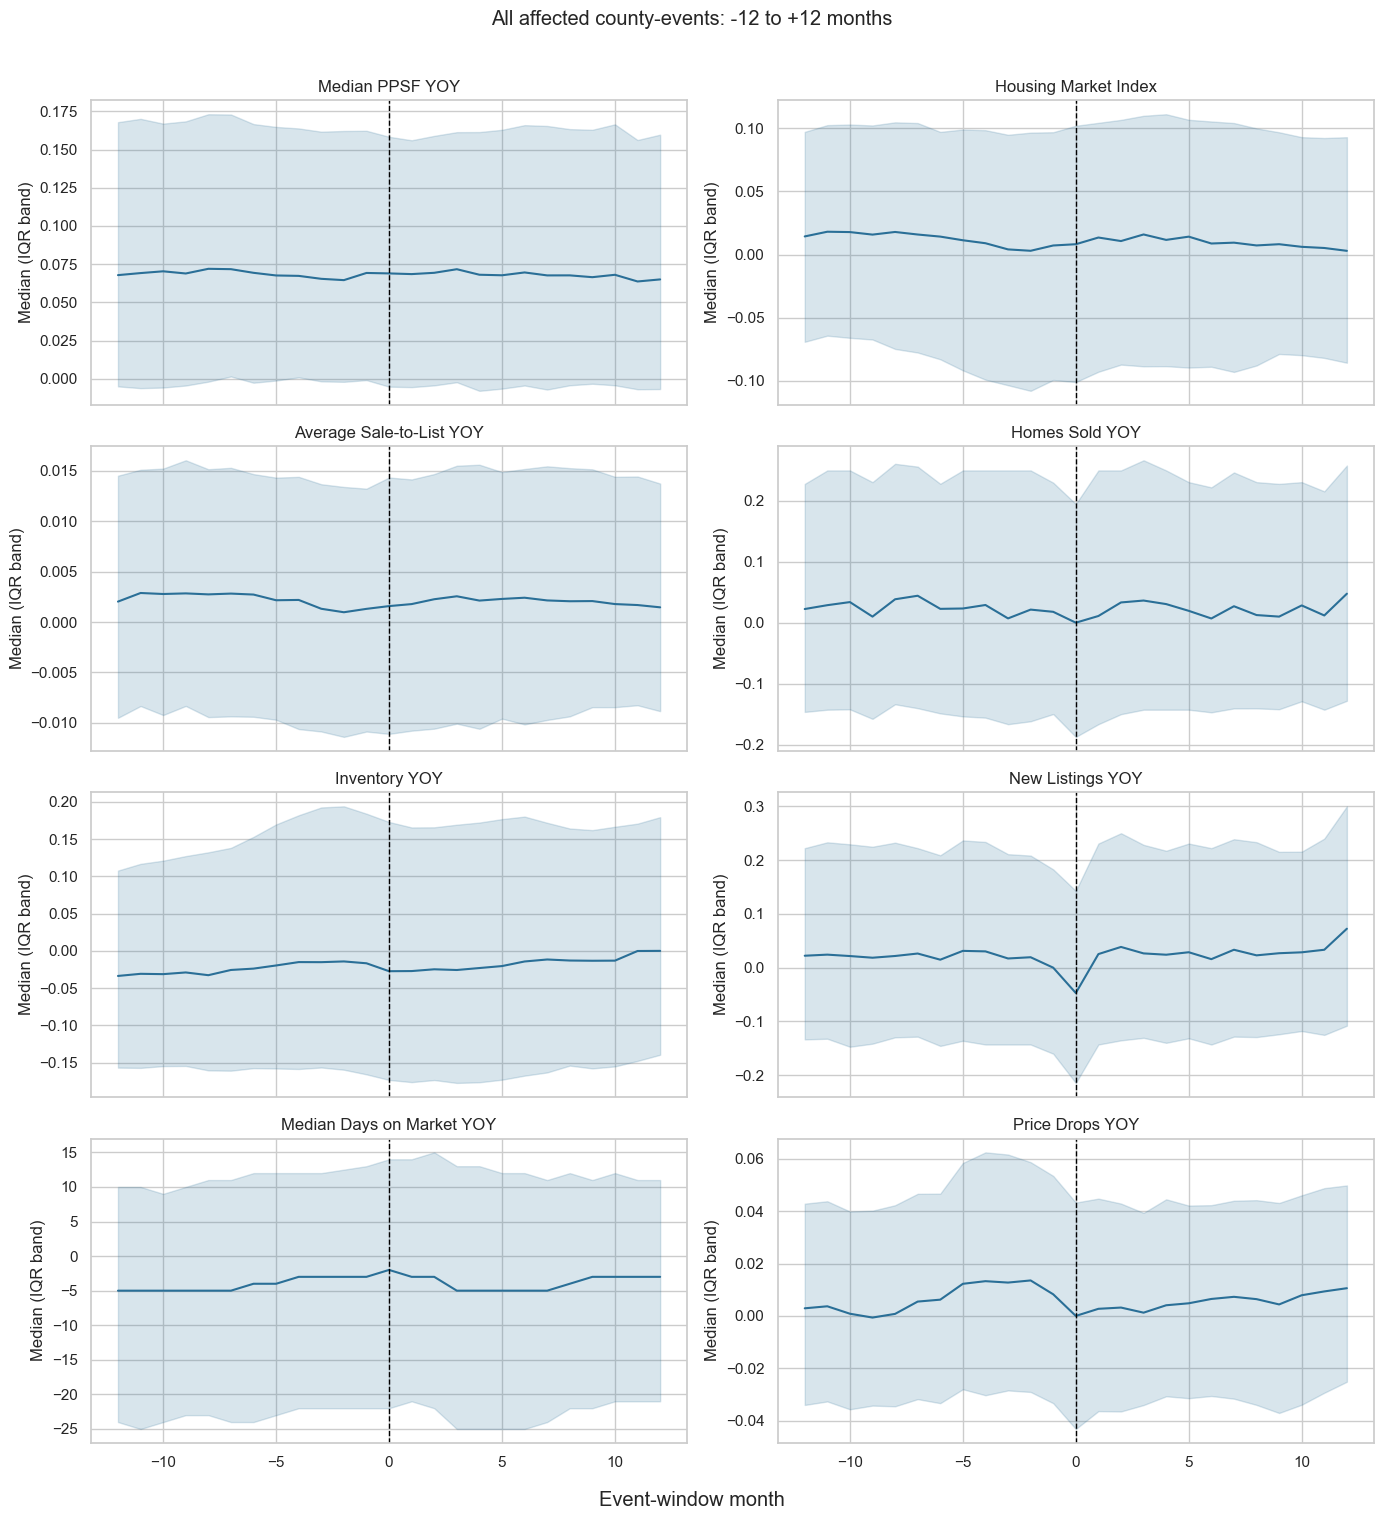

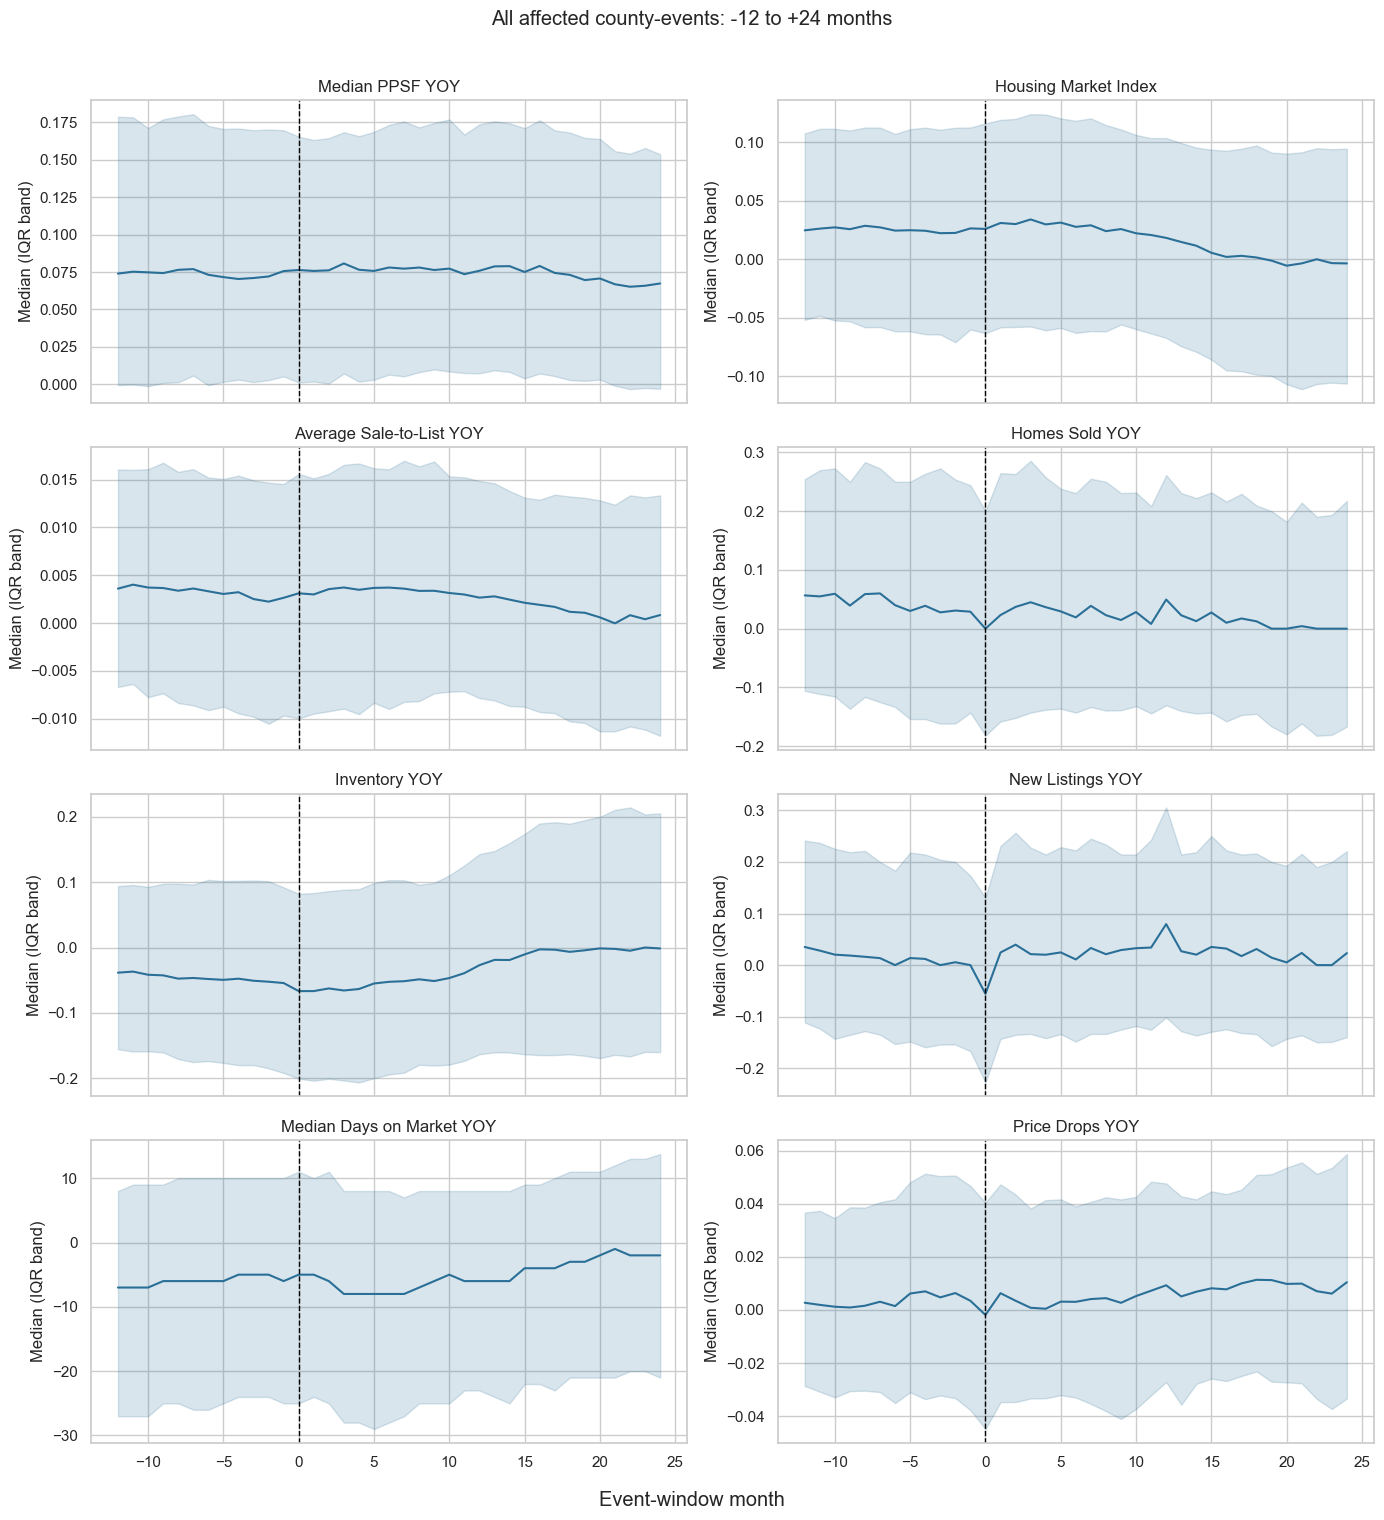

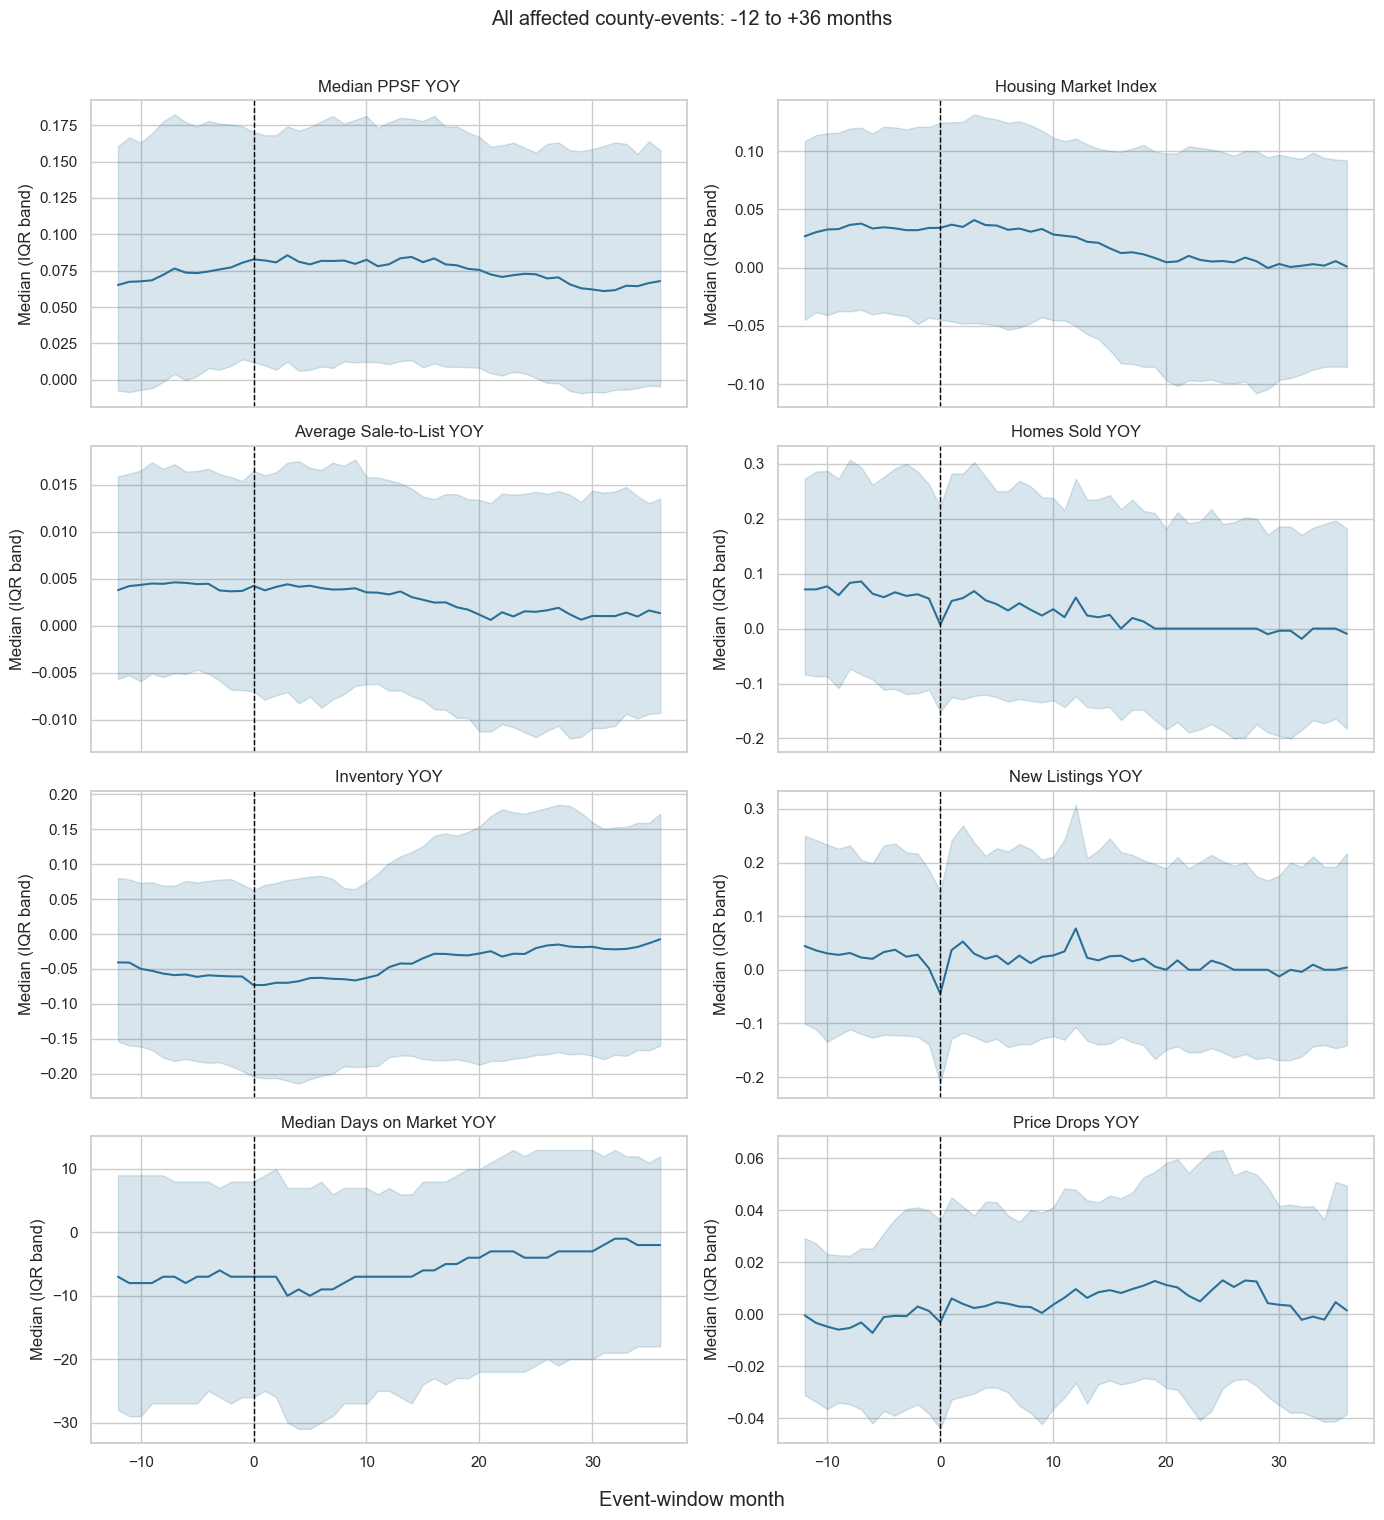

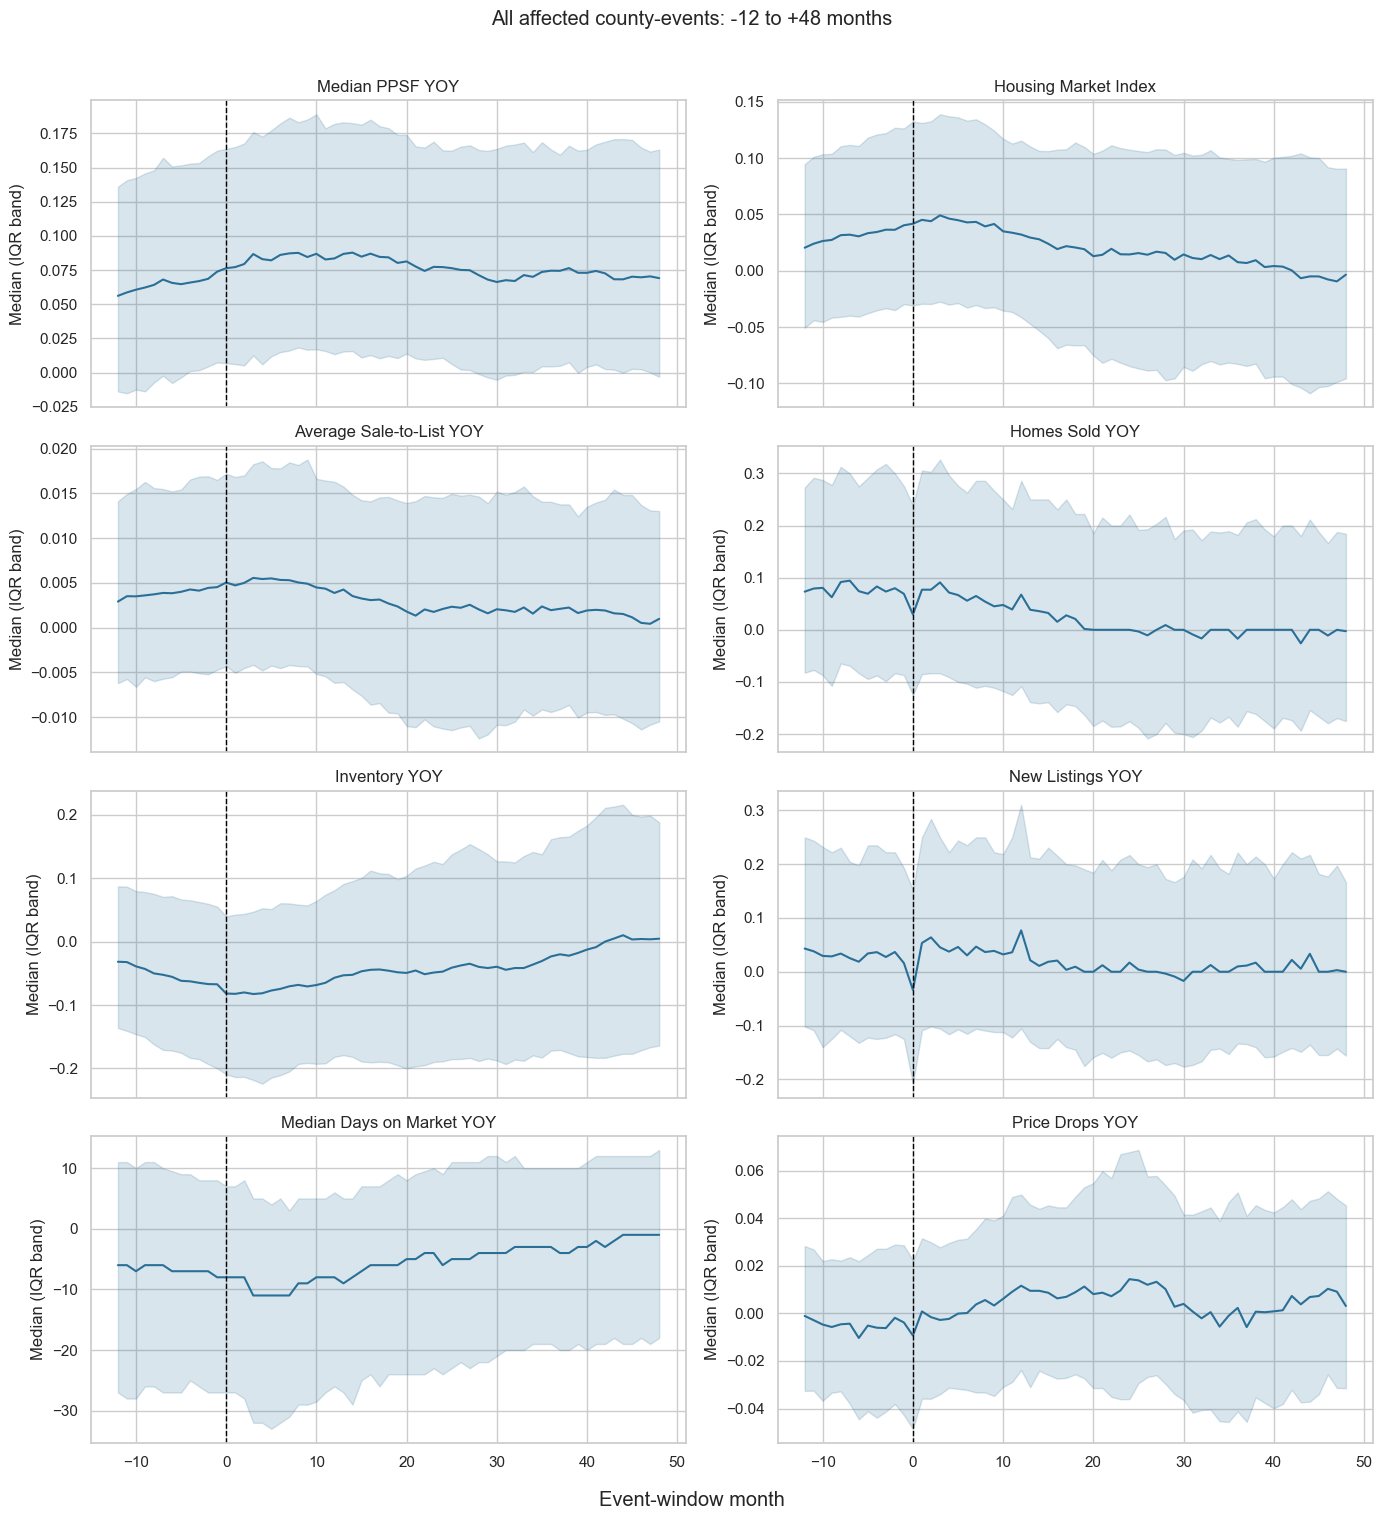

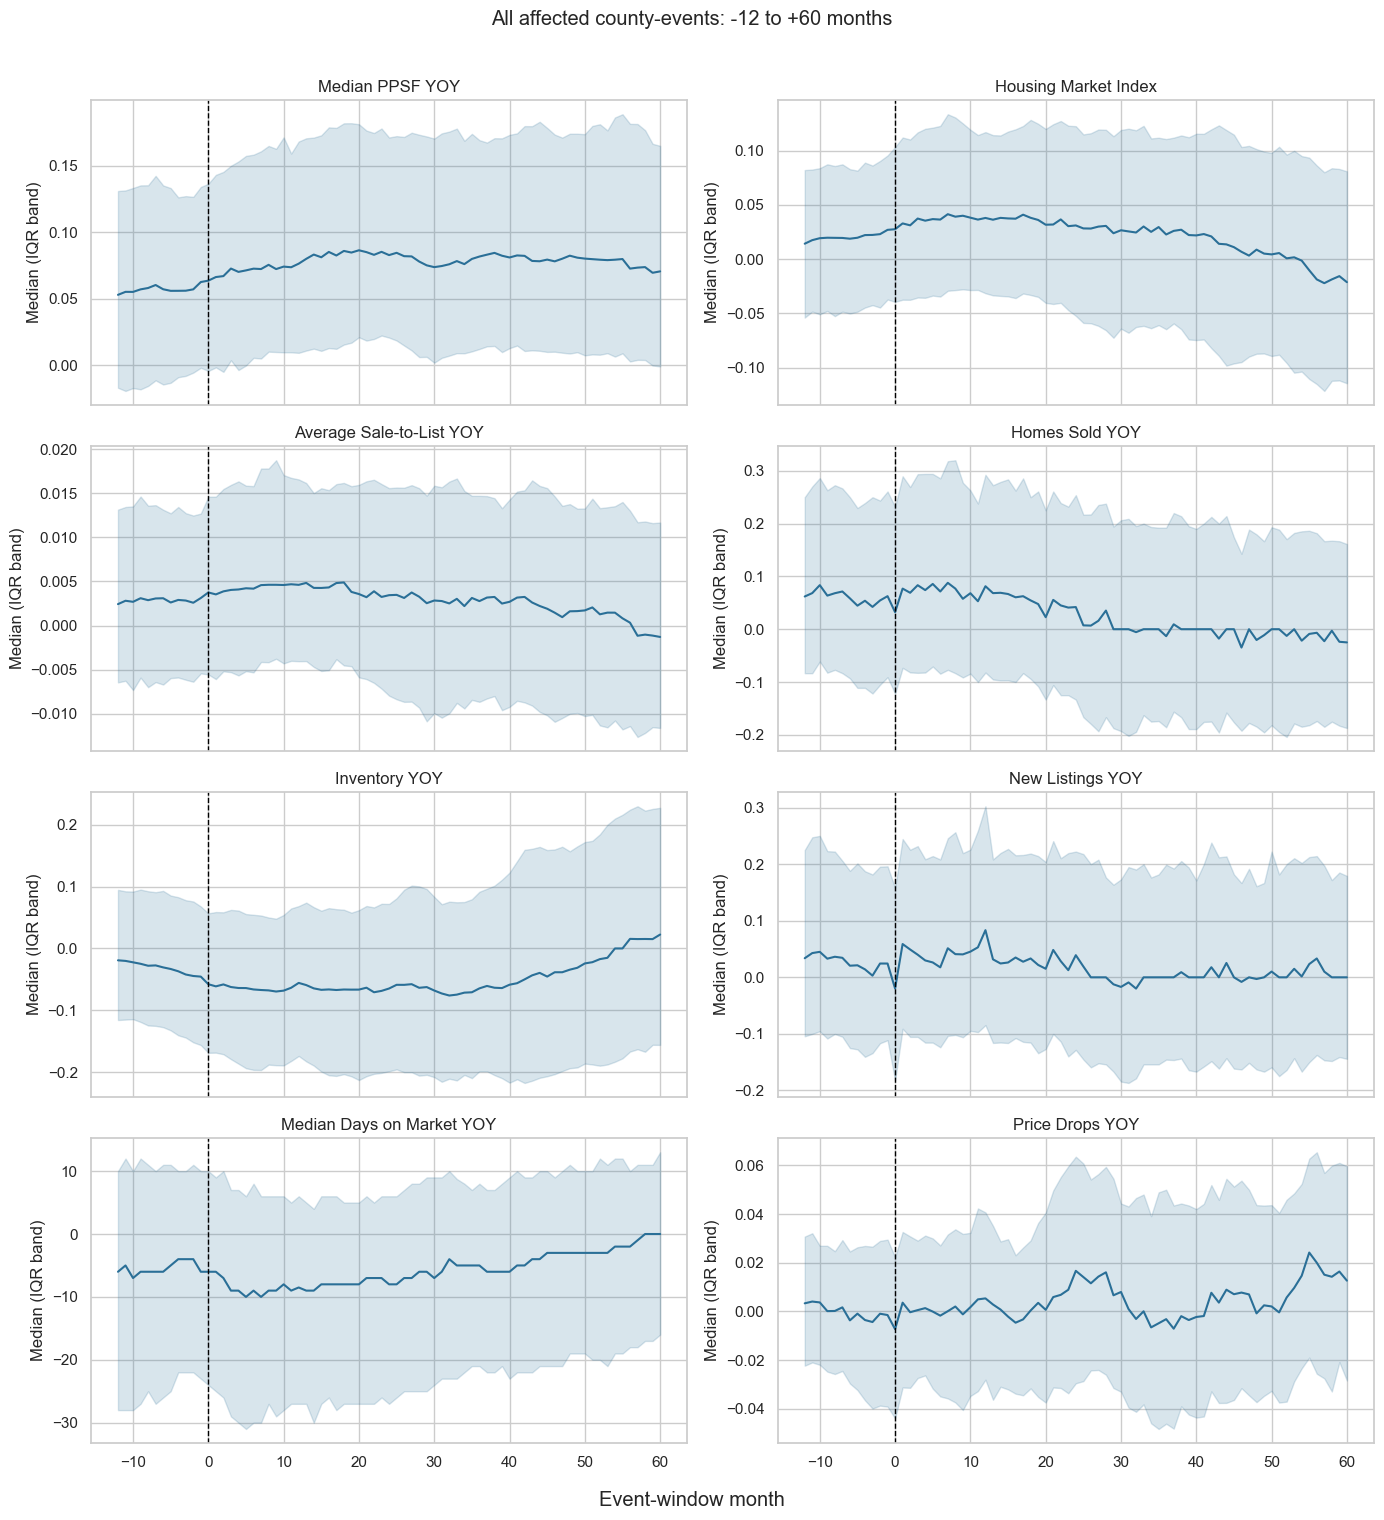

In [4]:
summary = con.execute(
    "SELECT * FROM analysis.housing_event_window_summary"
).df()
metric_labels = {
    "median_ppsf_yoy": "Median PPSF YOY",
    "housing_market_index": "Housing Market Index",
    "avg_sale_to_list_yoy": "Average Sale-to-List YOY",
    "homes_sold_yoy": "Homes Sold YOY",
    "inventory_yoy": "Inventory YOY",
    "new_listings_yoy": "New Listings YOY",
    "median_dom_yoy": "Median Days on Market YOY",
    "price_drops_yoy": "Price Drops YOY",
}
horizons = sorted(summary["horizon_months"].dropna().unique())

for horizon in horizons:
    data = summary.loc[
        (summary["aggregation_level"] == "all_counties")
        & (summary["horizon_months"] == horizon)
    ]
    fig, axes = plt.subplots(4, 2, figsize=(14, 15), sharex=True)
    for ax, (metric, label) in zip(axes.flat, metric_labels.items()):
        metric_data = data.loc[data["metric_name"] == metric].sort_values("event_window_month")
        ax.plot(metric_data["event_window_month"], metric_data["median_value"], color="#2a6f97")
        ax.fill_between(
            metric_data["event_window_month"],
            metric_data["q25_value"],
            metric_data["q75_value"],
            alpha=0.18,
            color="#2a6f97",
        )
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(label)
        ax.set_ylabel("Median (IQR band)")
    fig.suptitle(f"All affected county-events: -12 to +{horizon} months", y=1.01)
    fig.supxlabel("Event-window month")
    plt.tight_layout()
    plt.show()

## Aggregate results grouped by NRI risk rating

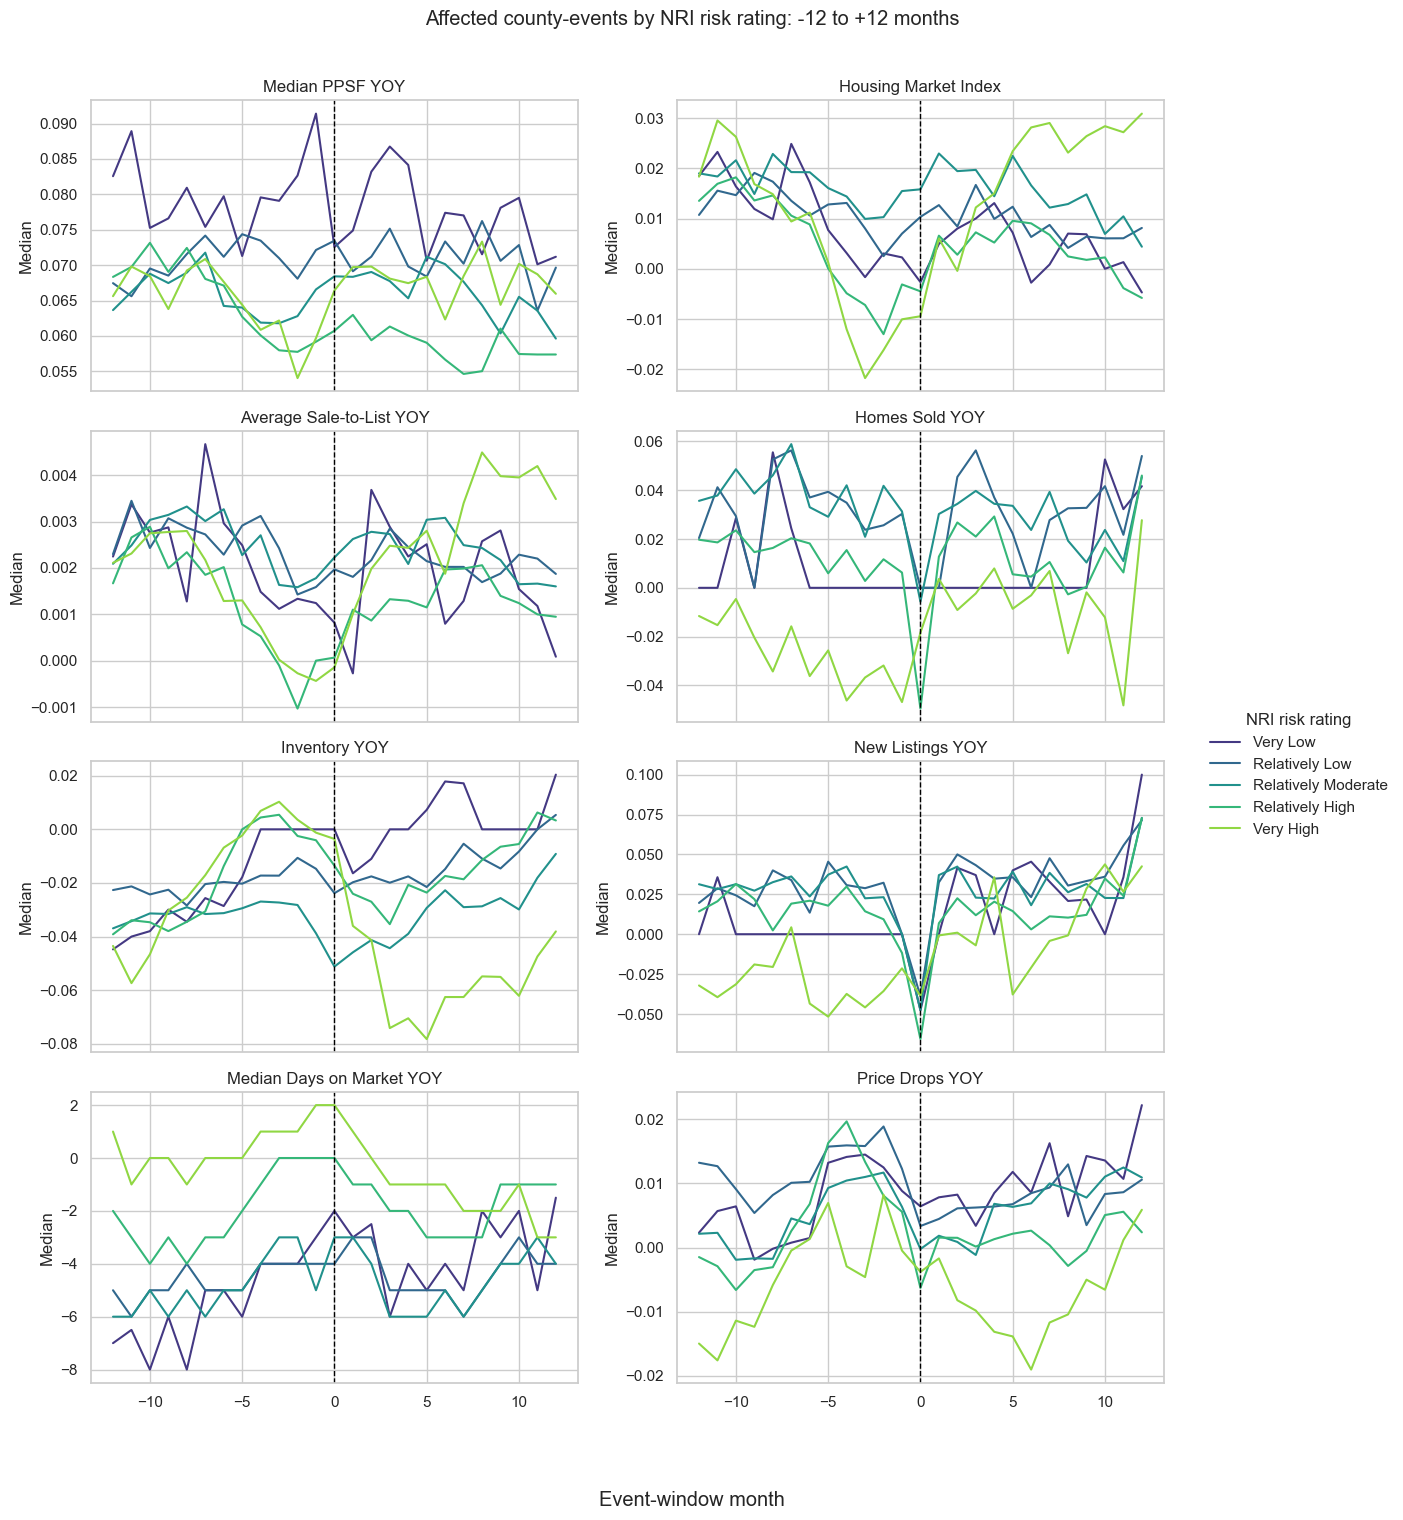

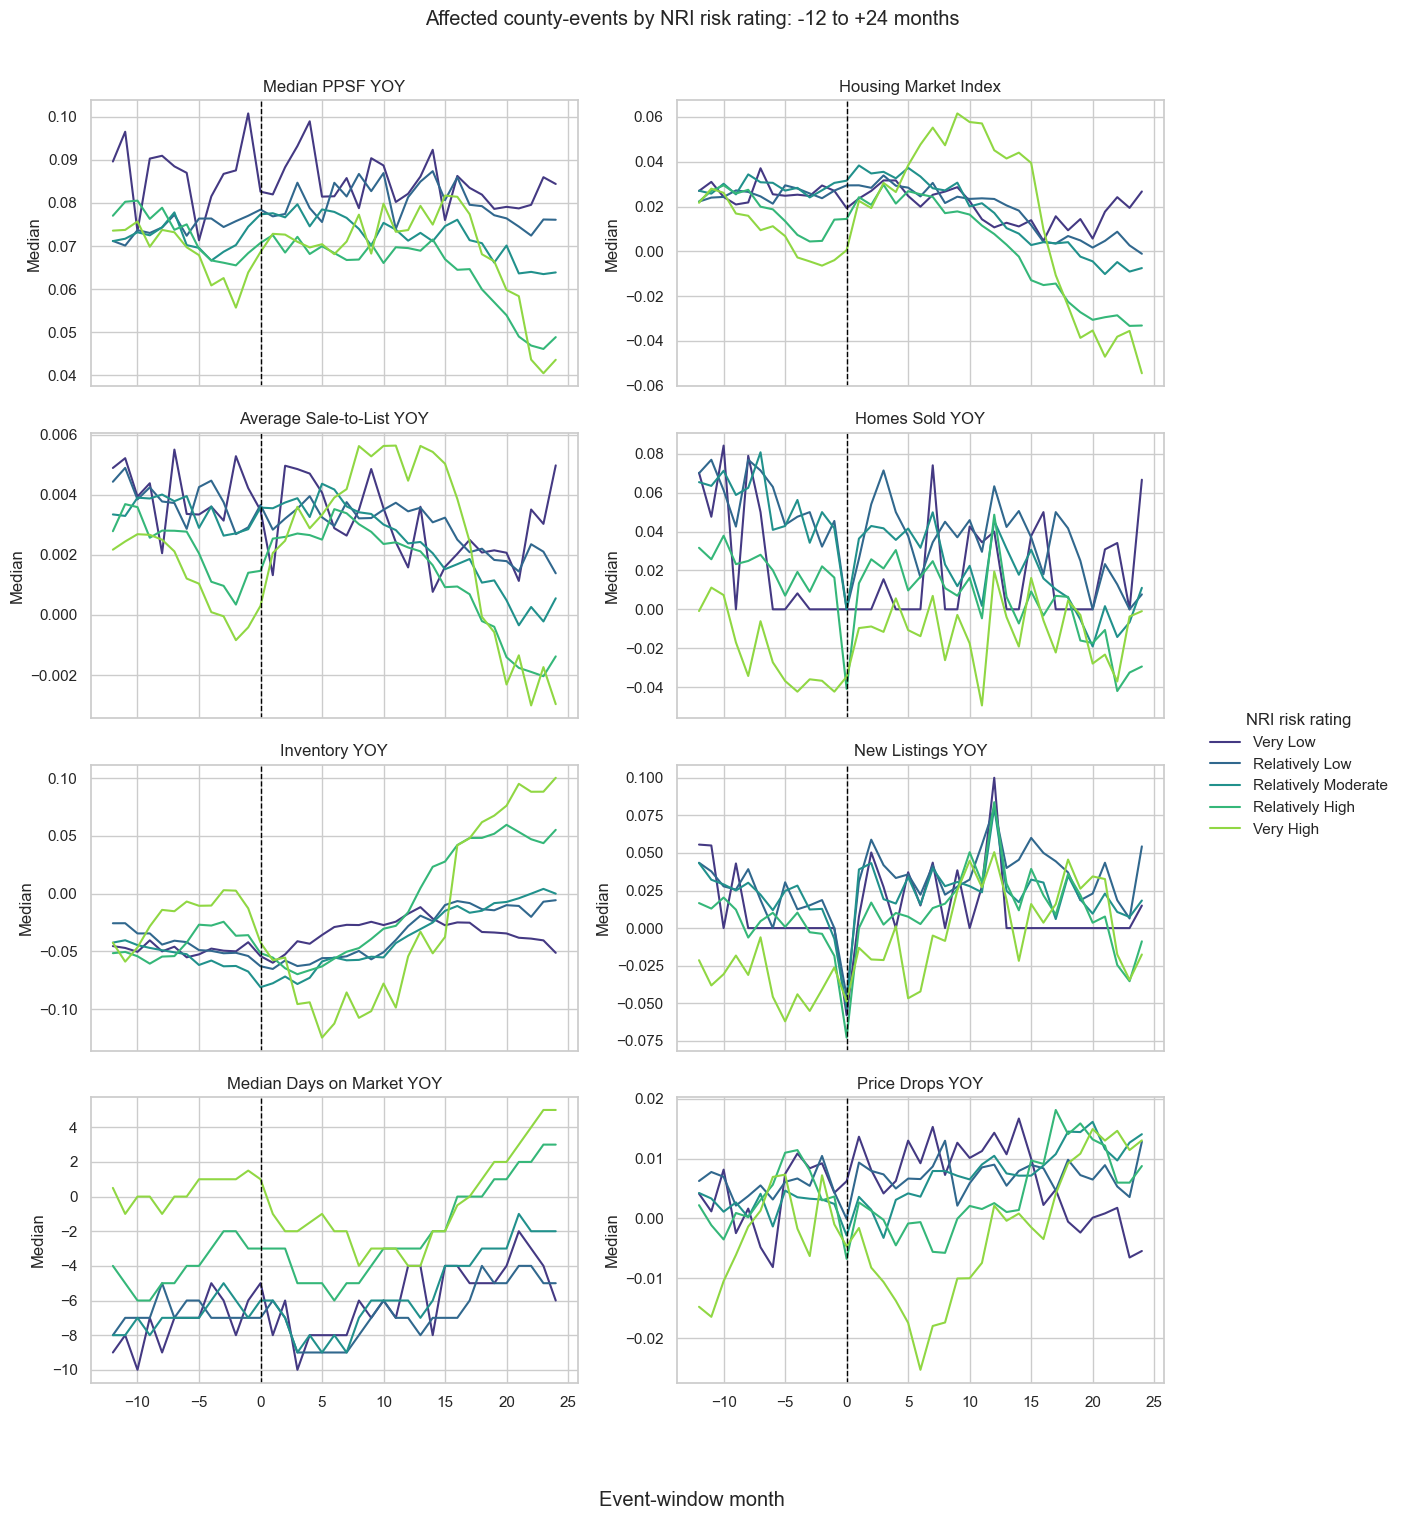

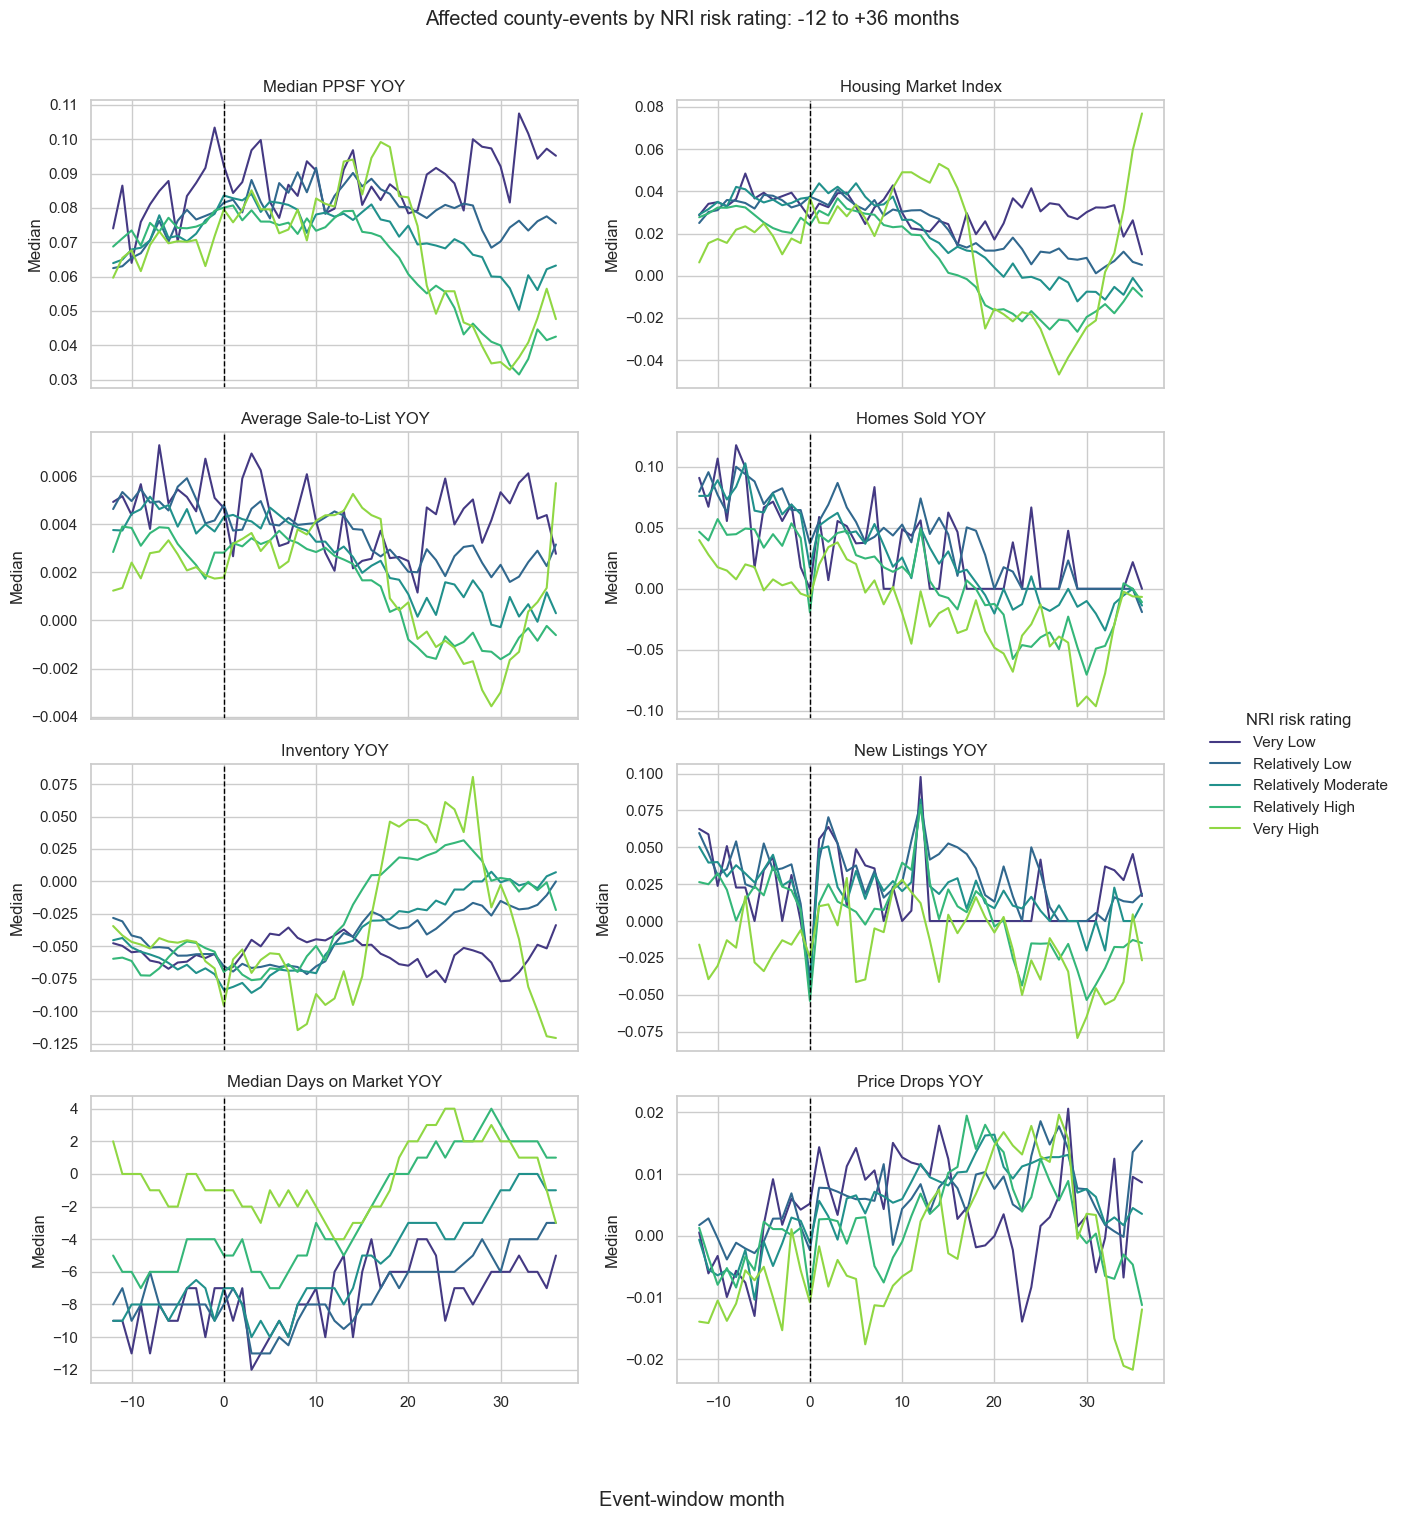

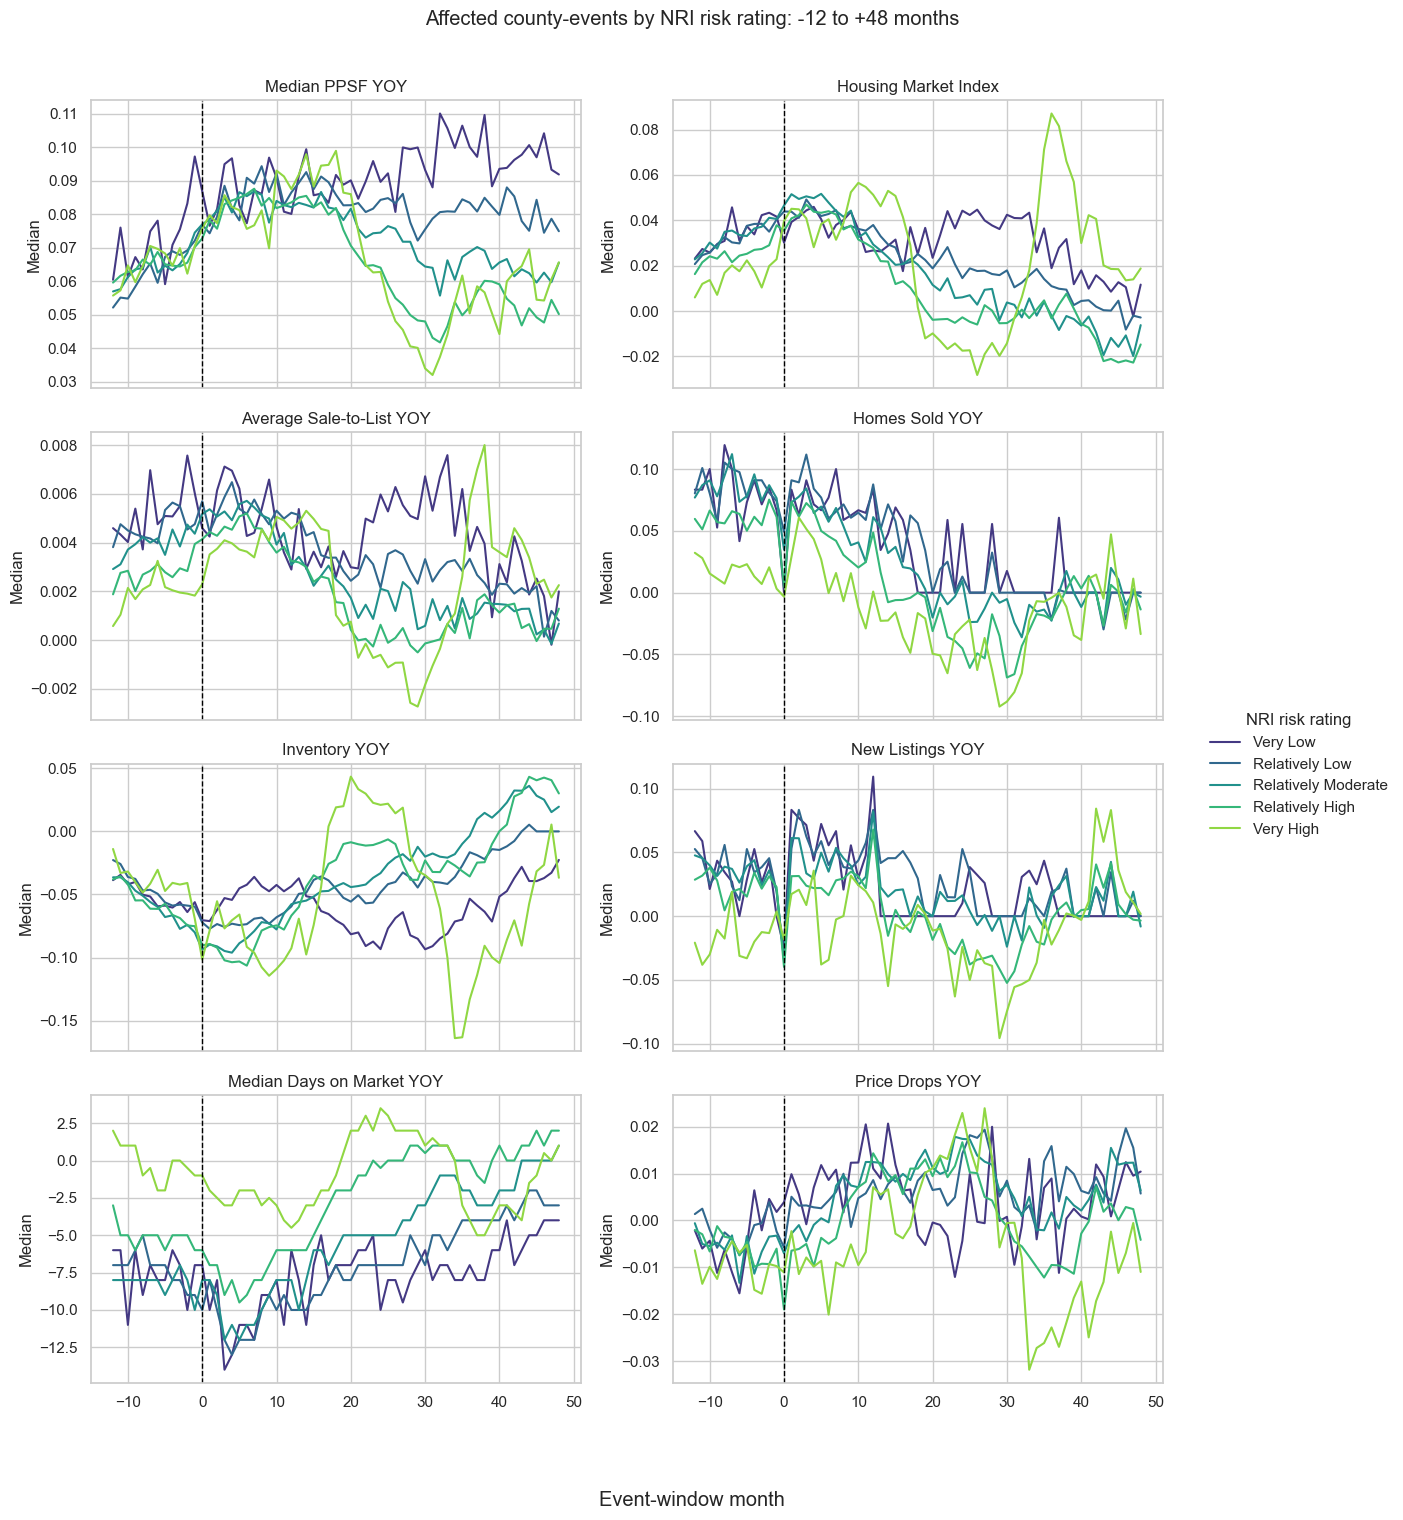

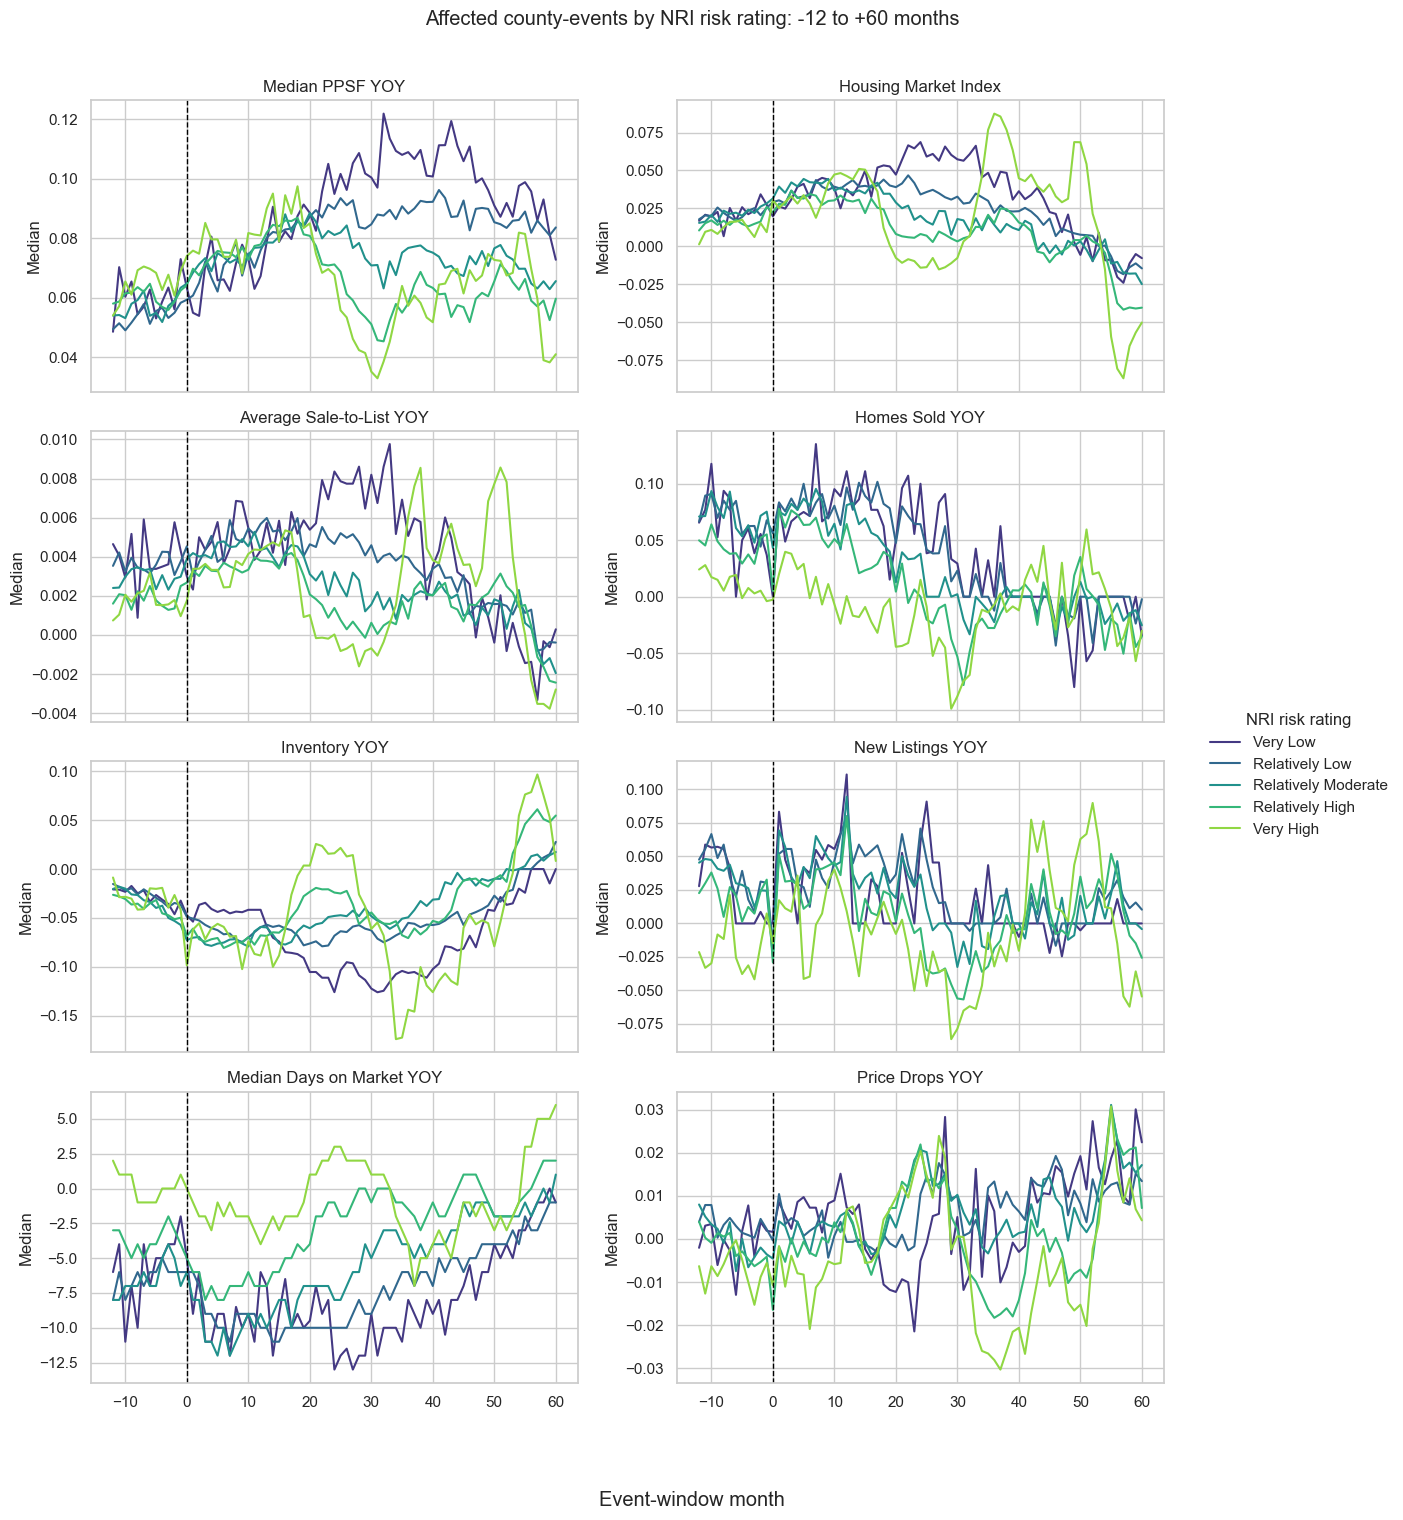

In [5]:
risk_order = [
    "Very Low", "Relatively Low", "Relatively Moderate",
    "Relatively High", "Very High",
]
palette = dict(zip(risk_order, sns.color_palette("viridis", len(risk_order))))

for horizon in horizons:
    data = summary.loc[
        (summary["aggregation_level"] == "nri_risk_rating")
        & (summary["horizon_months"] == horizon)
    ].copy()
    fig, axes = plt.subplots(4, 2, figsize=(14, 15), sharex=True)
    for ax, (metric, label) in zip(axes.flat, metric_labels.items()):
        metric_data = data.loc[data["metric_name"] == metric]
        for rating in risk_order:
            line = metric_data.loc[
                metric_data["risk_rating"] == rating
            ].sort_values("event_window_month")
            if not line.empty:
                ax.plot(
                    line["event_window_month"], line["median_value"],
                    label=rating, color=palette[rating],
                )
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(label)
        ax.set_ylabel("Median")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="NRI risk rating",
        loc="center left",
        bbox_to_anchor=(0.86, 0.5),
        frameon=False,
    )
    fig.suptitle(f"Affected county-events by NRI risk rating: -12 to +{horizon} months", y=1.01)
    fig.supxlabel("Event-window month")
    plt.tight_layout(rect=(0, 0.04, 0.85, 1))
    plt.show()

## Limitations

These are descriptive event-aligned medians, not causal estimates. Overlapping events
and repeated counties are retained, county-events are not statistically independent,
the complete-window rule changes the available sample by metric and horizon, and longer
horizons exclude more recent events. FEMA declaration and NOAA damage-reporting
processes also differ. Conclusions should therefore focus on visible patterns and
uncertainty, not treatment effects.

In [6]:
con.close()